<a href="https://colab.research.google.com/github/0ldspur/mnist-cnn-tuning/blob/from-95-to-99/Main_2025_ADC_CNN_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##IMPROVEMENT NOTE

**1.Increased Filter Sizes:**
The number of filters in the Conv2D layers was increased from 4 to 32, 64, and finally 128. >> I was aiming for highest accuracy.
Why: More filters allow the model to learn more detailed features from input images.

**2. Reduced Kernel Size:**
The kernel size was changed from (7,7) to (3,3).
Why: Smaller kernels are more effective at capturing fine-grained local patterns.

**3. Added Batch Normalization:**
Batch normalization was added after each convolutional layer.
Why: It stabilizes learning, speeds up convergence.


**4. Used ReduceLROnPlateau Callback:**
This callback was added to reduce the learning rate if validation accuracy plateaued.
Why: Helps the model overcome local minima and the model aim is just to improve accuracy. This avoided diminishing returns.

Several Epochs adjustment was done for traning with difference initial scenerios:
The model was trained for 10 epochs finally as improvements show strong results initially. instead of 20 for faster experimentation.


In [ ]:
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPool2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
import matplotlib.pyplot as plt
from tensorflow.keras.layers import BatchNormalization, Dropout
from tensorflow.keras.callbacks import ReduceLROnPlateau

In [ ]:
(X_train,y_train) , (X_test,y_test)=mnist.load_data()


In [ ]:
print(X_train.shape)
print(X_test.shape)

(60000, 28, 28)
(10000, 28, 28)


3


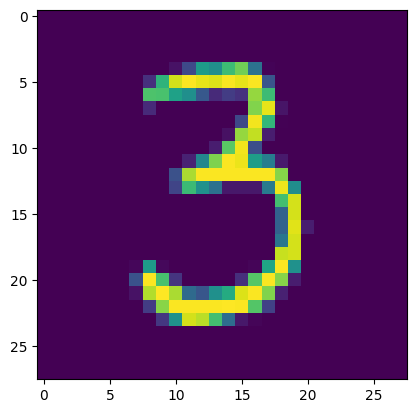

In [ ]:
Id= 50
print(y_train[Id])
plt.imshow(X_train[Id])

In [ ]:
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], X_train.shape[2], 1))
X_test = X_test.reshape((X_test.shape[0],X_test.shape[1],X_test.shape[2],1))

In [ ]:
print(X_train.shape)
print(X_test.shape)

(60000, 28, 28, 1)
(10000, 28, 28, 1)


In [ ]:
import tensorflow as tf


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


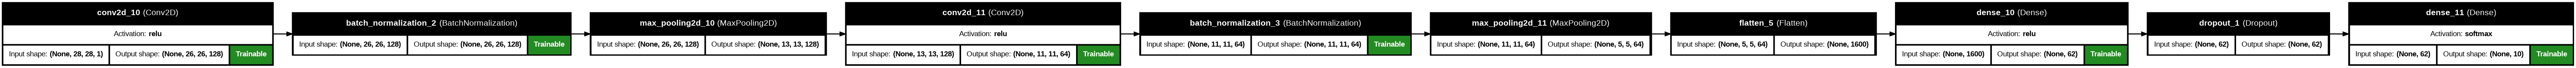

In [ ]:
model=Sequential()

#CNN
model.add(Conv2D(128,(3,3),activation='relu',input_shape=(28,28,1)))
model.add(BatchNormalization())
model.add(MaxPool2D(2,2))
model.add(Conv2D(64,(3,3),activation='relu'))
model.add(BatchNormalization())
model.add(MaxPool2D(2,2))


#ANN
model.add(Flatten())
model.add(Dense(62,activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(10,activation='softmax'))


tf.keras.utils.plot_model( model,
  to_file="model.png",
  show_shapes=True,
  show_dtype=False,
  show_layer_names=True,
  rankdir="LR",
  expand_nested=False,
  dpi=96,
  layer_range=None,
  show_layer_activations=True,
  show_trainable=True,
  )


In [ ]:
model.compile(loss='sparse_categorical_crossentropy',optimizer='Adam',metrics=['accuracy'])

In [ ]:
reduce_lr = ReduceLROnPlateau(monitor='val_accuracy', factor=0.5, patience=2, verbose=1)

In [ ]:
model.fit(X_train,y_train,epochs=10, validation_split=0.1, callbacks=[reduce_lr] )


Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 231s 137ms/step - accuracy: 0.9816 - loss: 0.0634 - val_accuracy: 0.9900 - val_loss: 0.0415 - learning_rate: 0.0010
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 224s 133ms/step - accuracy: 0.9830 - loss: 0.0567 - val_accuracy: 0.9915 - val_loss: 0.0367 - learning_rate: 0.0010
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 262s 133ms/step - accuracy: 0.9870 - loss: 0.0434 - val_accuracy: 0.9895 - val_loss: 0.0503 - learning_rate: 0.0010
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - accuracy: 0.9893 - loss: 0.0348
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 263s 134ms/step - accuracy: 0.9893 - loss: 0.0348 - val_accuracy: 0.9890 - val_loss: 0.0506 - learning_rate: 0.0010
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 260s 133ms/step - accuracy: 0.9920 - loss: 0.0262 - val_accuracy: 0.9920 - val_loss: 0.0460 - learning_rate: 5.0000e-04
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 265s 134m

In [ ]:
model.evaluate(X_test,y_test)


313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 29ms/step - accuracy: 0.9906 - loss: 0.0324


[0.02758222259581089, 0.9926000237464905]

In [ ]:
y_predict = model.predict(X_test)


313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 33ms/step


In [ ]:
y_predict[5]

array([5.0233564e-21, 9.9999994e-01, 7.8598975e-18, 4.4829336e-24,
       6.5943302e-17, 9.3377220e-22, 8.6945062e-18, 1.5815554e-14,
       1.3779193e-17, 1.2864200e-19], dtype=float32)

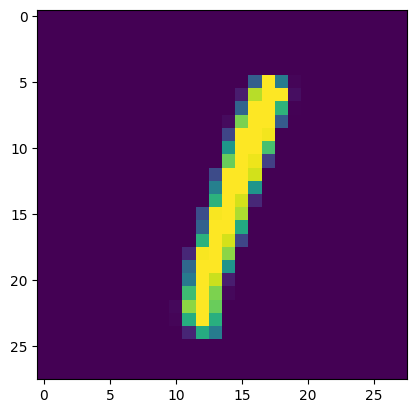

In [ ]:
import numpy as np
plt.imshow(X_test[5])

import matplotlib.pyplot as plt

In [ ]:
np.argmax(y_predict[5])


np.int64(1)

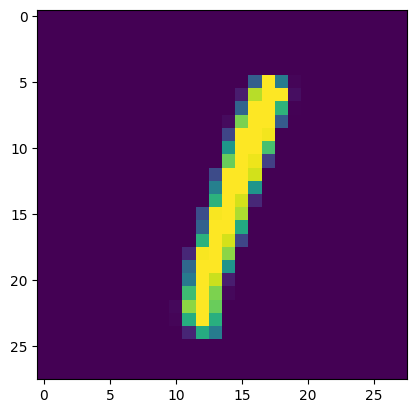

In [ ]:
plt.imshow(X_test[5])


Text(95.72222222222221, 0.5, 'Actual')

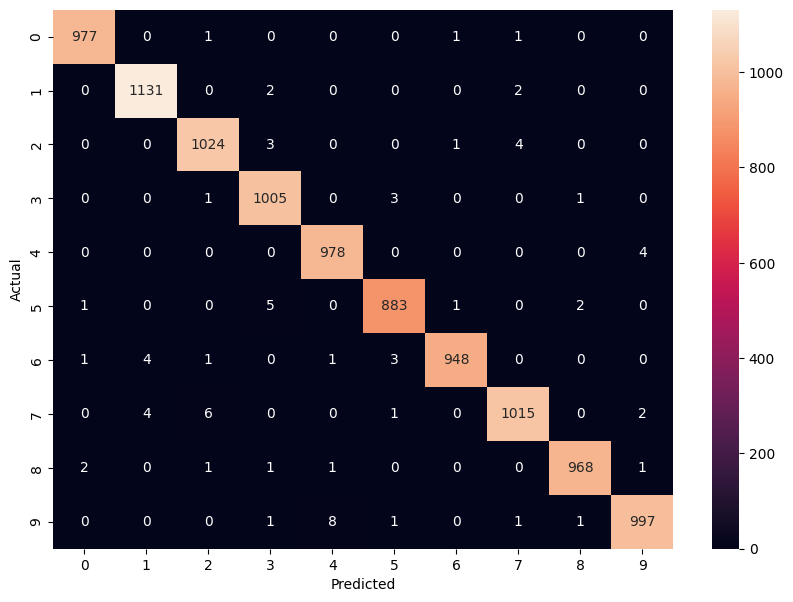

In [ ]:
import seaborn as sns
y_predict_labels=np.argmax(y_predict,axis=1)
#Confusion matrix
from sklearn.metrics import confusion_matrix
matrix=confusion_matrix(y_test,y_predict_labels)
#visualizaing confusion matrix with heatmap
plt.figure(figsize=(10,7))
sns.heatmap(matrix,annot=True,fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Actual')

In [ ]:
loss, acc = model.evaluate(X_test, y_test)
print(f"Final Test Accuracy: {acc * 100:.2f}%")


313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 29ms/step - accuracy: 0.9906 - loss: 0.0324
Final Test Accuracy: 99.26%
